# Qubit Scaling Experiment

How does W-state quality scale with number of qubits?

**Design:**
- Qubit sizes N ∈ {5, 10, 15, 20, 25}  (steps of 5)
- Shot count: 1000 per circuit
- 3 independent repetitions per N
- Metrics: Z-basis fidelity, X-basis entanglement witness ⟨W⟩
- Routing: swap-free best-chain (beam search)
- **Saved:** physical qubit chain for each N + full results → `qubit_scaling_results.json`

In [9]:
# ── Experiment parameters ──────────────────────────────────────────────────
QUBIT_SIZES  = [5, 10, 15, 20, 25, 30, 35, 40]
SHOTS        = 1000
N_REPS       = 1
BEAM_WIDTH   = 100
RESULTS_FILE = "qubit_scaling_results.json"

## 1. Connect to IQM Resonance

In [10]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

api_token = os.environ.get("IQM_TOKEN")
if not api_token:
    for p in [Path.cwd()/'.secrets'/'iqm_api_key', Path.cwd().parent/'.secrets'/'iqm_api_key']:
        if p.exists():
            api_token = p.read_text().strip()
            print(f"Using token from {p}")
            break
if not api_token:
    raise RuntimeError("Set IQM_TOKEN env var or place token in .secrets/iqm_api_key")
os.environ["IQM_TOKEN"] = api_token

provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend  = provider.get_backend()
print(f"Connected to: {backend.name}  ({backend.num_qubits} qubits)")

Connected to: IQMBackend  (54 qubits)


## 2. Load calibration data

In [11]:
import numpy as np
from iqm.qubit_selector.qubit_selector import CalibrationDataManager

cal = CalibrationDataManager().get_calibration_fidelities(backend)

cz_raw      = cal.get("CZ", {})
readout_raw = cal.get("readout", {})
t1_raw      = cal.get("t1", {})
t2_raw      = cal.get("t2", {})

def _parse_pair(fid_dict):
    out = {}
    for k, v in fid_dict.items():
        try:
            names = eval(k)
            idxs  = tuple(backend.qubit_name_to_index(n) for n in names)
            out[frozenset(idxs)] = float(v)
        except Exception:
            pass
    return out

def _parse_qubit(raw):
    out = {}
    for name, v in raw.items():
        try:
            out[backend.qubit_name_to_index(name)] = float(v)
        except Exception:
            pass
    return out

cz_fid  = _parse_pair(cz_raw)
ro_fid  = _parse_qubit(readout_raw)
t1_us   = _parse_qubit(t1_raw)
t2_us   = _parse_qubit(t2_raw)

cz_durations = []
if "cz" in backend.target:
    for qargs, props in backend.target["cz"].items():
        if props and props.duration:
            cz_durations.append(props.duration)
mean_cz_ns = np.mean(cz_durations) * 1e9 if cz_durations else 80.0

def t1_survival(phys, wait_ns, default_t1_us=200.0):
    t1_ns = t1_us.get(phys, default_t1_us) * 1e3
    return float(np.exp(-wait_ns / t1_ns))

def t2_survival(phys, wait_ns, default_t2_us=100.0):
    t2_ns = t2_us.get(phys, default_t2_us) * 1e3
    return float(np.exp(-wait_ns / t2_ns))

print(f"CZ fidelities: {len(cz_fid)} edges | Readout: {len(ro_fid)} qubits")
print(f"Mean CZ gate duration: {mean_cz_ns:.1f} ns")

CZ fidelities: 81 edges | Readout: 54 qubits
Mean CZ gate duration: 80.0 ns


## 3. Build topology + beam search helpers

In [12]:
import math
import networkx as nx

edges_list = list(backend.coupling_map.get_edges())
adj = {}
for u, v in edges_list:
    adj.setdefault(u, set()).add(v)
    adj.setdefault(v, set()).add(u)


def beam_search_chain(n, adj, cz_fid, ro_fid, t1_fn, t2_fn,
                      gate_ns, beam_width,
                      default_cz=0.90, default_ro=0.95):
    """Find the best length-n path on the coupling graph.

    Scoring uses the *average* circuit wait time for every qubit so the
    search is direction-agnostic: the beam explores all starting qubits
    equally without anchoring the chain to whichever qubit has the best T1.
    Orientation (which end becomes logical qubit 0) is decided separately
    by `best_orientation` after the path is found.
    """
    def log_s(x):
        return math.log(max(x, 1e-12))

    # Average wait time: each qubit is in the middle of the circuit on average
    avg_wait_ns = (n - 1) * 3 * gate_ns / 2

    beam = [(log_s(ro_fid.get(q, default_ro))
             + log_s(t1_fn(q, avg_wait_ns))
             + log_s(t2_fn(q, avg_wait_ns)),
             [q])
            for q in adj]
    beam.sort(reverse=True)
    beam = beam[:beam_width]

    for _ in range(n - 1):
        candidates = []
        for log_score, path in beam:
            last = path[-1]
            used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                new_log = (log_score
                           + log_s(cz_fid.get(frozenset((last, nbr)), default_cz))
                           + log_s(ro_fid.get(nbr, default_ro))
                           + log_s(t1_fn(nbr, avg_wait_ns))
                           + log_s(t2_fn(nbr, avg_wait_ns)))
                candidates.append((new_log, path + [nbr]))
        if not candidates:
            break
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]

    complete = [(s, p) for s, p in beam if len(p) == n]
    if not complete:
        raise RuntimeError(f"No complete chain of length {n} found")
    _, best_path = complete[0]
    return best_path


def best_orientation(path, cz_fid, ro_fid, t1_fn, t2_fn, gate_ns,
                     default_cz=0.90, default_ro=0.95):
    """Score path in both directions with actual position-dependent wait times.

    In the W-state circuit, logical qubit 0 is prepared first and then idles
    while the rest of the chain is entangled — so it accumulates the most
    decoherence. We pick whichever end gives the better overall score.
    Returns (oriented_path, score).
    """
    def log_s(x):
        return math.log(max(x, 1e-12))

    def score(p):
        n = len(p)
        s = 0.0
        for pos, q in enumerate(p):
            wait_ns = (n - 1 - pos) * 3 * gate_ns
            s += log_s(ro_fid.get(q, default_ro))
            s += log_s(t1_fn(q, wait_ns))
            s += log_s(t2_fn(q, wait_ns))
            if pos > 0:
                s += log_s(cz_fid.get(frozenset((p[pos - 1], q)), default_cz))
        return s

    fwd, rev = score(path), score(path[::-1])
    return (path, math.exp(fwd)) if fwd >= rev else (path[::-1], math.exp(rev))


def parse_counts(raw_counts, n_qubits):
    """IQM returns space-separated bitstrings; take the last (projective) register."""
    out = {}
    for bs, cnt in raw_counts.items():
        parts = bs.strip().split()
        key = parts[-1][-n_qubits:]
        out[key] = out.get(key, 0) + cnt
    return out


def z_fidelity(counts, n_qubits):
    """Fraction of counts that are valid single-excitation W-state bitstrings."""
    total = sum(counts.values())
    w_bitstrings = {format(1 << i, f'0{n_qubits}b') for i in range(n_qubits)}
    return sum(counts.get(s, 0) for s in w_bitstrings) / total if total else 0.0


def x_witness(counts, n_qubits):
    """Mean off-diagonal X-basis correlator — entanglement witness ⟨W⟩."""
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}

    def corr(i, j):
        return sum(
            (1 - 2 * int(b[-(i + 1)])) * (1 - 2 * int(b[-(j + 1)])) * p
            for b, p in probs.items()
        )

    vals = [corr(i, j) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    return float(np.mean(vals)) if vals else 0.0


print("Helpers defined.")


Helpers defined.


## 4. Find best chain for each qubit size and transpile circuits

In [13]:
from qiskit import transpile
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType

chains       = {}
chain_names  = {}
chain_scores = {}
circuits     = {}

for n in QUBIT_SIZES:
    print(f"\n── N={n} ──────────────────────────────")

    # Step 1: find best undirected path (direction-agnostic scoring)
    raw_path = beam_search_chain(
        n, adj, cz_fid, ro_fid,
        t1_fn=t1_survival, t2_fn=t2_survival,
        gate_ns=mean_cz_ns, beam_width=BEAM_WIDTH,
    )

    # Step 2: orient the path so the qubit that benefits most from being
    #         chain[0] (lowest accumulated decoherence) is placed first
    chain, score = best_orientation(
        raw_path, cz_fid, ro_fid,
        t1_fn=t1_survival, t2_fn=t2_survival,
        gate_ns=mean_cz_ns,
    )

    chains[n]       = chain
    chain_names[n]  = [backend.index_to_qubit_name(q) for q in chain]
    chain_scores[n] = score

    reversed_flag = " (reversed)" if chain == raw_path[::-1] else ""
    print(f"  Chain: {' → '.join(chain_names[n])}{reversed_flag}")
    print(f"  Score: {score:.4e}")

    qc_z = get_circuit(CircuitType.WSTATE, n); qc_z.measure_all()
    qc_x = get_circuit(CircuitType.WSTATE, n)
    qc_x.h(range(n)); qc_x.measure_all()

    qc_z_t = transpile(qc_z, backend=backend, initial_layout=chain,
                       routing_method="none", optimization_level=1)
    qc_x_t = transpile(qc_x, backend=backend, initial_layout=chain,
                       routing_method="none", optimization_level=1)

    assert qc_z_t.count_ops().get("swap", 0) == 0
    assert qc_x_t.count_ops().get("swap", 0) == 0
    circuits[n] = (qc_z_t, qc_x_t)
    print(f"  Depth Z/X: {qc_z_t.depth()} / {qc_x_t.depth()}  |  SWAPs: 0 ✓")

print("\nAll circuits ready.")



── N=5 ──────────────────────────────
  Chain: QB11 → QB12 → QB6 → QB2 → QB1
  Score: 8.5022e-01
  Depth Z/X: 14 / 15  |  SWAPs: 0 ✓

── N=10 ──────────────────────────────
  Chain: QB11 → QB12 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37
  Score: 5.2716e-01
  Depth Z/X: 24 / 25  |  SWAPs: 0 ✓

── N=15 ──────────────────────────────
  Chain: QB2 → QB1 → QB5 → QB11 → QB12 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB45 → QB44
  Score: 2.4825e-01
  Depth Z/X: 34 / 35  |  SWAPs: 0 ✓

── N=20 ──────────────────────────────
  Chain: QB2 → QB1 → QB5 → QB11 → QB12 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB36 → QB35 → QB34 → QB33 → QB25 → QB24 → QB23
  Score: 7.8568e-02
  Depth Z/X: 44 / 45  |  SWAPs: 0 ✓

── N=25 ──────────────────────────────
  Chain: QB2 → QB1 → QB5 → QB11 → QB12 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB36 → QB35 → QB27 → QB26 → QB25 → QB33 → QB34 → QB42 → QB48 → QB52 → QB53 → QB49
  Score: 1.9785e-02
  Depth Z/X: 54 /

## 5. Submit all jobs

For each (N, rep) pair we submit both Z-basis and X-basis circuits.  
All jobs are submitted first to minimise wall-clock time.

In [14]:
# Submit hardware jobs only if no saved results exist; otherwise reload counts
# from the saved JSON (drift-fair re-analysis without burning credits).
import json as _json, os as _os
job_registry = {}
total_jobs = 0
saved_path = RESULTS_FILE if _os.path.exists(RESULTS_FILE) else None
if saved_path:
    print(f"  Found {saved_path} — will reload counts in the next cell, "
          f"skipping submission.")
else:
    for n in QUBIT_SIZES:
        qc_z_t, qc_x_t = circuits[n]
        for rep in range(N_REPS):
            job_z = backend.run(qc_z_t, shots=SHOTS)
            job_x = backend.run(qc_x_t, shots=SHOTS)
            job_registry[(n, rep)] = (job_z, job_x, job_z.job_id(), job_x.job_id())
            total_jobs += 2
            print(f"  N={n:2d} | rep={rep} | shots={SHOTS} → "
                  f"Z:{job_z.job_id()[:8]}…  X:{job_x.job_id()[:8]}…")
    print(f"\nSubmitted {total_jobs} jobs total.")


  N= 5 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=10 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=15 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=20 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=25 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=30 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=35 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…
  N=40 | rep=0 | shots=1000 → Z:019e107e…  X:019e107e…

Submitted 16 jobs total.


## 6. Retrieve results and compute metrics

In [15]:
# Either fetch counts from the freshly-submitted jobs, or reload from JSON.
import json as _json, os as _os, math as _math, numpy as _np
results = {n: [] for n in QUBIT_SIZES}

if _os.path.exists(RESULTS_FILE) and not job_registry:
    saved = _json.load(open(RESULTS_FILE))
    print(f"Reloading from {RESULTS_FILE} (no fresh jobs).")
    for n_str, runs in saved["results"].items():
        n = int(n_str)
        if n not in QUBIT_SIZES:
            continue
        for r in runs:
            counts_z = r.get("counts_z") or {}
            counts_x = r.get("counts_x") or {}
            results[n].append({
                "rep":        r["rep"],
                "fidelity_z": r["fidelity_z"],
                "witness_x":  r["witness_x"],
                "job_id_z":   r.get("job_id_z", ""),
                "job_id_x":   r.get("job_id_x", ""),
                "counts_z":   counts_z,
                "counts_x":   counts_x,
            })
            print(f"  N={n} rep={r['rep']}: fid={r['fidelity_z']:.3f}  "
                  f"W={r['witness_x']:.4f}  (loaded)")
else:
    for (n, rep), (job_z, job_x, jid_z, jid_x) in job_registry.items():
        print(f"Fetching N={n} rep={rep} ...", end=" ")
        counts_z = parse_counts(job_z.result().get_counts(), n)
        counts_x = parse_counts(job_x.result().get_counts(), n)
        fz = z_fidelity(counts_z, n)
        wx = x_witness(counts_x, n)
        results[n].append({
            "rep": rep, "fidelity_z": fz, "witness_x": wx,
            "job_id_z": jid_z, "job_id_x": jid_x,
            "counts_z": counts_z, "counts_x": counts_x,
        })
        print(f"fid={fz:.3f}  W={wx:.4f}")

print("\nAll results collected.")


Fetching N=5 rep=0 ... [05-10 08:06:53;I] Waiting for job 019e107e-b78c-75c1-bd67-6f41de3af588 to finish...


Progress in queue:  33%|███▎      | 1/3 [1:13:51<2:27:42, 4431.04s/it]


[05-10 09:20:46;I] Waiting for job 019e107e-ba5e-74d1-bbf4-7074de6be9f8 to finish...
fid=0.935  W=0.2368
Fetching N=10 rep=0 ... [05-10 09:20:48;I] Waiting for job 019e107e-bd1a-7103-a30b-ea6ffc65a4a6 to finish...
[05-10 09:20:51;I] Waiting for job 019e107e-bffc-70f1-a3c0-adc17b6b604d to finish...
fid=0.733  W=0.5310
Fetching N=15 rep=0 ... [05-10 09:20:53;I] Waiting for job 019e107e-c2c1-7f42-8851-d721b909bd86 to finish...
[05-10 09:20:55;I] Waiting for job 019e107e-c5fa-79a3-9d9f-662427fb02b0 to finish...
fid=0.587  W=0.6230
Fetching N=20 rep=0 ... [05-10 09:20:58;I] Waiting for job 019e107e-c8d0-7612-88c7-2931ca64a81a to finish...
[05-10 09:21:01;I] Waiting for job 019e107e-cca1-7cc3-b9f3-a88be0d48089 to finish...
fid=0.345  W=0.5979
Fetching N=25 rep=0 ... [05-10 09:21:03;I] Waiting for job 019e107e-cf7a-7c82-92b5-73ed348ba948 to finish...
[05-10 09:21:05;I] Waiting for job 019e107e-d288-70e0-8a57-e2e0c6d2dc82 to finish...
fid=0.171  W=0.5405
Fetching N=30 rep=0 ... [05-10 09:21:08

## 7. Save results to JSON

Everything saved — chains, scores, per-rep metrics, raw counts, job IDs.

In [16]:
import json
import datetime

output = {
    "metadata": {
        "timestamp":   datetime.datetime.utcnow().isoformat() + "Z",
        "backend":     backend.name,
        "num_qubits":  backend.num_qubits,
        "qubit_sizes": QUBIT_SIZES,
        "shots":       SHOTS,
        "n_reps":      N_REPS,
        "beam_width":  BEAM_WIDTH,
    },
    "chains": {
        str(n): {
            "indices":    chains[n],
            "names":      chain_names[n],
            "beam_score": chain_scores[n],
        }
        for n in QUBIT_SIZES
    },
    "results": {
        str(n): results[n]
        for n in QUBIT_SIZES
    },
}

with open(RESULTS_FILE, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved → {RESULTS_FILE}")
print(json.dumps(output["chains"], indent=2))

Saved → qubit_scaling_results.json
{
  "5": {
    "indices": [
      10,
      11,
      5,
      1,
      0
    ],
    "names": [
      "QB11",
      "QB12",
      "QB6",
      "QB2",
      "QB1"
    ],
    "beam_score": 0.8502208206126418
  },
  "10": {
    "indices": [
      10,
      11,
      5,
      6,
      12,
      13,
      21,
      29,
      28,
      36
    ],
    "names": [
      "QB11",
      "QB12",
      "QB6",
      "QB7",
      "QB13",
      "QB14",
      "QB22",
      "QB30",
      "QB29",
      "QB37"
    ],
    "beam_score": 0.5271596857935248
  },
  "15": {
    "indices": [
      1,
      0,
      4,
      10,
      11,
      5,
      6,
      12,
      13,
      21,
      29,
      28,
      36,
      44,
      43
    ],
    "names": [
      "QB2",
      "QB1",
      "QB5",
      "QB11",
      "QB12",
      "QB6",
      "QB7",
      "QB13",
      "QB14",
      "QB22",
      "QB30",
      "QB29",
      "QB37",
      "QB45",
      "QB44"
    ],
    "beam_score": 

C:\Users\MI\AppData\Local\Temp\ipykernel_9392\1363572184.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":   datetime.datetime.utcnow().isoformat() + "Z",


## 8. Summary table

In [17]:
# Honest per-n significance: pair-correlator sample-std / sqrt(n_pairs).
# Each pair shares qubits with others, so independent shot noise underestimates
# the std of the mean; the cross-pair sample std is the conservative number.
import math
print(f"{'N':>4} {'chain':^50} {'fid_z':>9} {'<W>':>9} "
      f"{'2/N':>8} {'<W>/(2/N)':>11} {'sigma_avg':>11} {'sigma above 0':>14}")
print("-" * 130)
for n in QUBIT_SIZES:
    ideal_x = 2.0 / n
    reps_data = results[n]
    fzs = [r["fidelity_z"] for r in reps_data]
    wxs = [r["witness_x"]  for r in reps_data]
    chain_str = " → ".join(chain_names[n])
    if len(chain_str) > 48:
        chain_str = chain_str[:22] + " … " + chain_str[-23:]

    # Conservative sigma: std across pair correlators / sqrt(n_pairs)
    pair_vals = []
    for r in reps_data:
        counts = r["counts_x"]
        if not counts:
            continue
        total = sum(counts.values())
        for i in range(n):
            for j in range(i + 1, n):
                v = 0
                for bs, c in counts.items():
                    bs2 = bs.replace(" ", "")
                    ei = 1 - 2 * int(bs2[-(i + 1)])
                    ej = 1 - 2 * int(bs2[-(j + 1)])
                    v += ei * ej * c
                pair_vals.append(v / total)
    if pair_vals:
        sigma_avg = float(np.std(pair_vals)) / math.sqrt(len(pair_vals))
        sig_z = float(np.mean(wxs)) / sigma_avg if sigma_avg > 0 else float("inf")
    else:
        sigma_avg, sig_z = float("nan"), float("nan")

    print(f"{n:>4} {chain_str:^50} {np.mean(fzs):>9.3f} {np.mean(wxs):>9.4f} "
          f"{ideal_x:>8.4f} {(np.mean(wxs)/ideal_x if ideal_x else 0):>11.2f} "
          f"{sigma_avg:>11.4f} {sig_z:>+12.1f}σ")
print()
print("Note: <W> below the quantum ideal 2/N at small N (e.g. n=5: 56% of ideal)")
print("means the prepared state is noisier than W. <W> above 2/N at large N is")
print("not an unphysical violation — the measured state is not a clean W either.")
print("The classical mixture of single-excitation strings has <X_i X_j>=0; what")
print("the witness rules out is exactly that classical baseline.")


   N                       chain                            fid_z       <W>      2/N   <W>/(2/N)   sigma_avg  sigma above 0
----------------------------------------------------------------------------------------------------------------------------------
   5           QB11 → QB12 → QB6 → QB2 → QB1                0.935    0.2368   0.4000        0.59      0.0162        +14.6σ
  10  QB11 → QB12 → QB6 → QB … 22 → QB30 → QB29 → QB37      0.733    0.5310   0.2000        2.65      0.0090        +59.1σ
  15  QB2 → QB1 → QB5 → QB11 … 29 → QB37 → QB45 → QB44      0.587    0.6230   0.1333        4.67      0.0072        +86.1σ
  20  QB2 → QB1 → QB5 → QB11 … 33 → QB25 → QB24 → QB23      0.345    0.5979   0.1000        5.98      0.0082        +72.8σ
  25  QB2 → QB1 → QB5 → QB11 … 48 → QB52 → QB53 → QB49      0.171    0.5405   0.0800        6.76      0.0120        +44.9σ
  30  QB2 → QB1 → QB5 → QB11 … 17 → QB18 → QB26 → QB27      0.049    0.4773   0.0667        7.16      0.0124        +38.5σ
  35  Q

## 9. Plot scaling

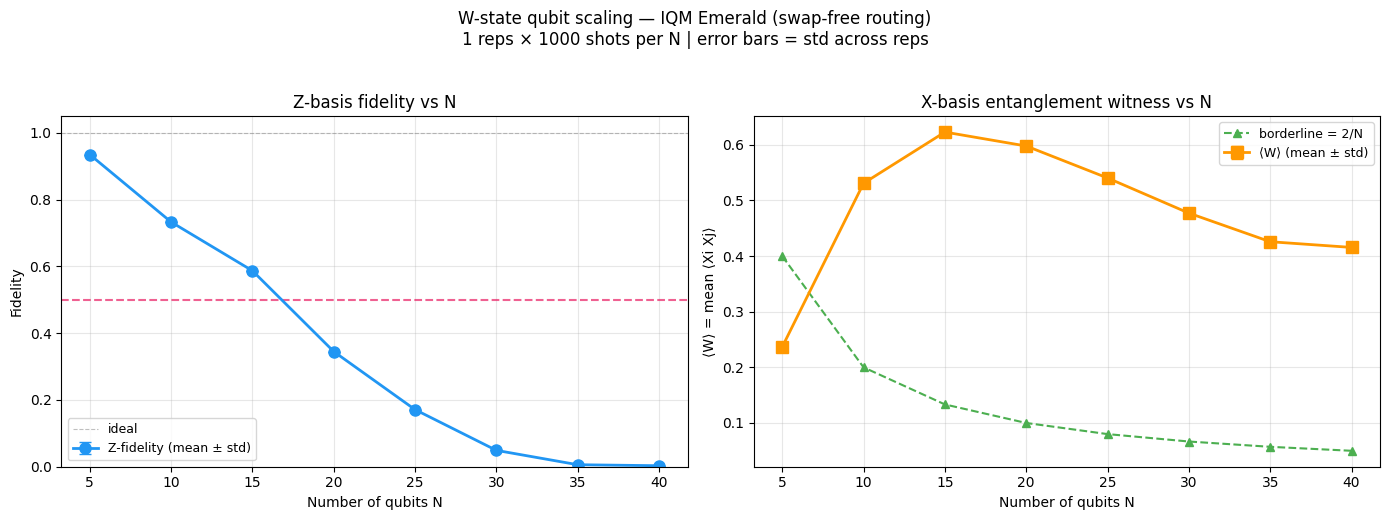

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fz_means, fz_stds = [], []
wx_means, wx_stds = [], []
borderlines = []

for n in QUBIT_SIZES:
    reps_data = results[n]
    fzs = [r["fidelity_z"] for r in reps_data]
    wxs = [r["witness_x"]  for r in reps_data]
    fz_means.append(np.mean(fzs))
    fz_stds.append(np.std(fzs))
    wx_means.append(np.mean(wxs))
    wx_stds.append(np.std(wxs))
    borderlines.append(2.0 / n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_z, ax_x = axes

ax_z.errorbar(QUBIT_SIZES, fz_means, yerr=fz_stds,
              color="#2196F3", marker="o", capsize=4, linewidth=2, markersize=8,
              label="Z-fidelity (mean ± std)")
ax_z.axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.5, label="ideal")
ax_z.set_xlabel("Number of qubits N")
ax_z.set_ylabel("Fidelity")
ax_z.set_title("Z-basis fidelity vs N")
ax_z.set_ylim(0, 1.05)
ax_z.set_xticks(QUBIT_SIZES)
ax_z.legend(fontsize=9)
ax_z.grid(True, alpha=0.3)

ax_x.errorbar(QUBIT_SIZES, wx_means, yerr=wx_stds,
              color="#FF9800", marker="s", capsize=4, linewidth=2, markersize=8,
              label="⟨W⟩ (mean ± std)")
ax_x.plot(QUBIT_SIZES, borderlines,
          color="#4CAF50", ls="--", lw=1.5, marker="^", markersize=6,
          label="borderline = 2/N")
ax_x.set_xlabel("Number of qubits N")
ax_x.set_ylabel("⟨W⟩ = mean ⟨Xi Xj⟩")
ax_x.set_title("X-basis entanglement witness vs N")
ax_x.set_xticks(QUBIT_SIZES)
ax_x.legend(fontsize=9)
ax_x.grid(True, alpha=0.3)
ax_z.axhline(0.5, color="#E91E63", lw=1.5, ls="--", alpha=0.7, label="borderline = 0.5")
plt.suptitle(
    f"W-state qubit scaling — IQM Emerald (swap-free routing)\n"
    f"{N_REPS} reps × {SHOTS} shots per N | error bars = std across reps",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig("qubit_scaling.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Visualize qubit topology — chains on the chip

In [19]:
import sys
sys.path.insert(0, '..')
from src.visualization import plot_device_topology, _device_layout
import matplotlib.pyplot as plt

# cz_fid uses frozenset keys; plot_device_topology wants (min, max) tuple keys
cz_fid_tuples = {(min(fs), max(fs)): v for fs, v in cz_fid.items()}

# metrics dict: {qubit_idx: {"readout_fidelity": float}}
metrics = {q: {"readout_fidelity": ro_fid[q]} for q in ro_fid}

pos = _device_layout(backend)

fig, axes = plt.subplots(1, len(QUBIT_SIZES), figsize=(24, 8))
for ax, n in zip(axes, QUBIT_SIZES):
    chain = chains[n]
    hi_edges = [(chain[i], chain[i + 1]) for i in range(len(chain) - 1)]
    plot_device_topology(
        backend, metrics=metrics, cz_fidelities=cz_fid_tuples,
        color_by="readout_fidelity",
        highlight_qubits=chain, highlight_edges=hi_edges,
        title=f"N = {n}", ax=ax, pos=pos,
        show_labels=True, spotlight=True,
    )
fig.suptitle(
    "IQM Emerald — W-state qubit chains per N\n"
    "Node color = readout fidelity  |  Edge color = CZ fidelity  |  Red = selected chain",
    fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig("qubit_topology_chains.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved qubit_topology_chains.png")

ModuleNotFoundError: No module named 'src'